|<img style="float:left;" src="../images/usherb_transp.gif"> |Pierre Proulx, ing, professeur|
|:---|:---|
|**Département de génie chimique et de génie biotechnologique. Programme de génie biotechnologique** | |
|**été 2019** | **GBT201-Phénomènes d'échanges I**|


8B5

In [10]:
#
# Initialiser sympy et l'affichage des équationa
#
from pheno import *

In [11]:
#
# Définir les variables,paramètres et fonctions qui sont utilisées
# Le bilan est identique au début, c'est seulement quand on met
# la loi de comportement que cela change
#
x,L,rho,mu_0,B,DP,tau_0=sp.symbols('x,L,rho,mu_0,B,DP,tau_0')
tau=sp.Function('tau_xz')(x)
v_z=sp.Function('v_z')(x)

In [12]:
tau_xz=-mu_0*(sp.Derivative(v_z,x))+tau_0
eq1=sp.Eq(tau_xz-(DP/L)*x,0)

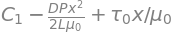

In [13]:
#
# Solution
#
v_z=sp.dsolve(eq1,v_z).rhs
display(v_z)    # Pour afficher seulement avec vz(r) à gauche du signe =

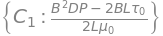

In [14]:
# La constante inconnue est obtenue avec la condition vz(r)=0 en r=R
#
C1=sp.symbols('C1')
constante=sp.solve((v_z.subs(x,B),0),C1)
display(constante)

In [15]:
v_z=v_z.subs(constante)
display(v_z.simplify())

Maintenant voyons la forme de cette expression sous format graphique. On doit choisir des valeurs pour les paramètres. Il est intéressant de voir les variations de profils en fonction de ces paramètres rhéologiques m et n.

In [16]:
# Ici on va trouver le point du profil ou le cisaillement devient inférieur
# au taux seuil (tau_0). A l'intérieur de ce point, le fluide se comporte comme 
# un solide, sans gradient de vitesse.
X_0=sp.solve(sp.diff(v_z,x),x)
display(X_0)

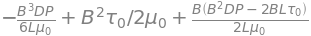

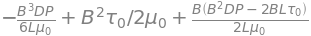

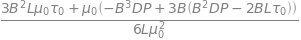

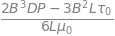

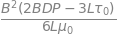

In [25]:
debit=sp.integrate(v_z,(x,0,B))
display(debit)
display(debit.powsimp())
display(debit.simplify())
display(debit.radsimp())
display(debit.cancel())
display(debit.together())

In [8]:
dico={'rho':1000, 'mu_0':0.1, 'B':0.05,'L':100,'DP':200}
def f(T0):
    X0=X_0[0].subs(dico).subs(tau_0,T0)
    v_zplot=v_z.subs(dico).subs(tau_0,T0)
    v_zmax=v_zplot.subs(x,X0)
    if X0<B.subs(dico):
        p = sp.plot((v_zmax,(x,0,X0)),\
            (v_zplot,(x,X0,B.subs(dico))),legend=True,show=False) 
        p[0].line_color = 'blue'
        p[1].line_color='red'
        p[0].label="tau"
        p[1].label=''
        p.show()
    else:
        print("Pas d'écoulement, le taux de cisaillement maximum est inférieur au seuil")
graphe=interactive(f,T0=(0.01,0.1,0.001));

In [9]:
display(graphe);

interactive(children=(FloatSlider(value=0.055, description='T0', max=0.1, min=0.01, step=0.001), Output()), _d…